In [17]:
import warnings
warnings.filterwarnings('ignore')

In [18]:
#loading python classes and packages
import os
import numpy as np
import librosa
import pandas as pd
from sklearn.metrics import accuracy_score
from keras.utils.np_utils import to_categorical
from keras.layers import  MaxPooling2D
from keras.layers import Dense, Dropout, Activation, Flatten, RepeatVector, Bidirectional, LSTM, GRU
from keras.layers import Convolution2D
from keras.models import Sequential, Model
from keras.callbacks import ModelCheckpoint
import pickle
from sklearn.model_selection import train_test_split
import traceback
from keras.layers import Conv1D, MaxPooling1D, RepeatVector#loading CNN1D
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt   
import joblib

In [2]:
#code to load urban8K dataset file with 10 different labels and audio files
dataset = pd.read_csv("UrbanSound8K.csv")
labels = np.unique(dataset['class'].ravel())
dataset

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.000000,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.500000,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.500000,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.000000,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.500000,72.500000,1,5,2,children_playing
...,...,...,...,...,...,...,...,...
8727,99812-1-2-0.wav,99812,159.522205,163.522205,2,7,1,car_horn
8728,99812-1-3-0.wav,99812,181.142431,183.284976,2,7,1,car_horn
8729,99812-1-4-0.wav,99812,242.691902,246.197885,2,7,1,car_horn
8730,99812-1-5-0.wav,99812,253.209850,255.741948,2,7,1,car_horn


In [3]:
#code to load 50 classes dataset which contains only two audio files called Crackle fire and glass breaking
labels = labels.tolist()
labels.append("crackling_fire")
labels.append("glass_breaking")
labels = np.asarray(labels)
glass_fire = pd.read_csv("50classes.csv")
glass_fire

,filename,fold,target,category,esc10,src_file,take
0,1-17150-A-12.wav,1,12,crackling_fire,True,17150,A
1,1-17565-A-12.wav,1,12,crackling_fire,True,17565,A
2,1-17742-A-12.wav,1,12,crackling_fire,True,17742,A
3,1-17808-A-12.wav,1,12,crackling_fire,True,17808,A
4,1-17808-B-12.wav,1,12,crackling_fire,True,17808,B
...,...,...,...,...,...,...,...
75,5-233607-A-39.wav,5,39,glass_breaking,False,233607,A
76,5-257642-A-39.wav,5,39,glass_breaking,False,257642,A
77,5-260432-A-39.wav,5,39,glass_breaking,False,260432,A
78,5-260433-A-39.wav,5,39,glass_breaking,False,260433,A


In [4]:
#defining global variables to store X and Y training data
X = []
Y = []

In [5]:
#code to read all audio files and then extract Melspectorgram features by converting all audios to mono stereo and drop
#down sample rate 16000
if os.path.exists("model/X.txt.npy"):
    X = np.load('model/X.txt.npy')
    Y = np.load('model/Y.txt.npy')
else:
    X.clear()
    Y.clear()
    dataset = dataset.values
    for i in range(len(dataset)):#loop all audio file from dataset
        folder = dataset[i, 5]
        name = dataset[i,0]
        filename = 'Dataset/fold'+str(folder)+"/"+name
        label = dataset[i,6]
        try:
            audio, sample_rate = librosa.load(filename, res_type='kaiser_fast', sr=16000, mono=True) #read audio
            mels = np.mean(librosa.feature.melspectrogram(y = audio, sr=sample_rate).T,axis=0)#extract mel spec features         
            if mels is not None:
                X.append(mels)#add labels and features to X and Y array
                Y.append(label)            
        except Exception:
            pass     
    glass_fire = glass_fire.values
    for i in range(len(dataset)):#read glass and fire dataset audio
        name = dataset[i,0]
        filename = 'Dataset/2classes/'+name
        label = dataset[i,3]
        try:
            audio, sample_rate = librosa.load(filename, res_type='kaiser_fast', sr=16000, mono=True) 
            mels = np.mean(librosa.feature.melspectrogram(y = audio, sr=sample_rate).T,axis=0)         
            if mels is not None:
                X.append(mels)
                if label == 'crackling_fire':
                    Y.append(10)
                else:
                    Y.append(11)
        except Exception:
            pass     
print("Dataset Audio Files Cleaning and Melspectorgram Features extraction completed")
print("Total labels found in Dataset = "+str(len(labels)))
print("Total audio files found in Dataset = "+str(X.shape[0]))        

Dataset Audio Files Cleaning and Melspectorgram Features extraction completed
Total labels found in Dataset = 12
Total audio files found in Dataset = 8812


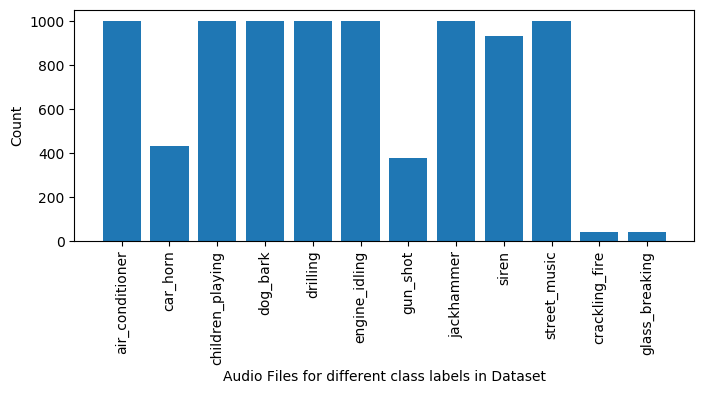

In [6]:
#visualizing class labels count found in dataset
names, count = np.unique(Y, return_counts = True)
height = count
bars = labels
y_pos = np.arange(len(bars))
plt.figure(figsize = (8, 3)) 
plt.bar(y_pos, height)
plt.xticks(y_pos, bars)
plt.xlabel("Audio Files for different class labels in Dataset")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

In [7]:
#shuffling and processing audio data files
X_file = 'model/shuffled_X.pkl'
Y_file = 'model/shuffled_Y.pkl'

# Check if the shuffled dataset files already exist
if os.path.exists(X_file) and os.path.exists(Y_file):
    # Load the shuffled and encoded data if they already exist
    X = joblib.load(X_file)
    Y = joblib.load(Y_file)
    print("Loaded shuffled and one-hot encoded dataset.")
else:
    # Shuffle the dataset
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)
    X = X[indices]
    Y = Y[indices]

    # Apply one-hot encoding to the labels
    Y = to_categorical(Y)

    # Save the shuffled and encoded dataset
    joblib.dump(X, X_file)
    joblib.dump(Y, Y_file)

    print("Shuffling and one-hot encoding completed and dataset saved.")

# Now, X and Y are available for further use
print("Shuffling Dataset audio files completed")

Loaded shuffled and one-hot encoded dataset.
Shuffling Dataset audio files completed


In [8]:
#split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
print("Dataset Train & Test Split Details")
print("80% audio files used to train algorithms : "+str(X_train.shape[0]))
print("20% audio files used to test algorithms : "+str(X_test.shape[0]))

Dataset Train & Test Split Details
80% audio files used to train algorithms : 7049
20% audio files used to test algorithms : 1763


In [21]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []

ML_Model = []
acc = []
prec = []
rec = []
f1 = []

#function to call for storing the results
def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    acc.append(round(a, 3))
    prec.append(round(b, 3))
    rec.append(round(c, 3))
    f1.append(round(d, 3))

In [10]:
def calculateMetrics(algorithm, predict, y_test):
    a = accuracy_score(y_test,predict)*100
    p = precision_score(y_test, predict,average='macro') * 100
    r = recall_score(y_test, predict,average='macro') * 100
    f = f1_score(y_test, predict,average='macro') * 100
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+" Accuracy  :  "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FScore    : "+str(f))    
    conf_matrix = confusion_matrix(y_test, predict) 
    plt.figure(figsize =(8, 5)) 
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g");
    ax.set_ylim([0,len(labels)])
    plt.title(algorithm+" Confusion matrix") 
    plt.xticks(rotation=90)
    plt.ylabel('True class') 
    plt.xlabel('Predicted class') 
    plt.show() 



CNN1D Accuracy  :  92.85309132161089
CNN1D Precision : 94.68790982093863
CNN1D Recall    : 86.11960713171362
CNN1D FScore    : 88.60218698882531


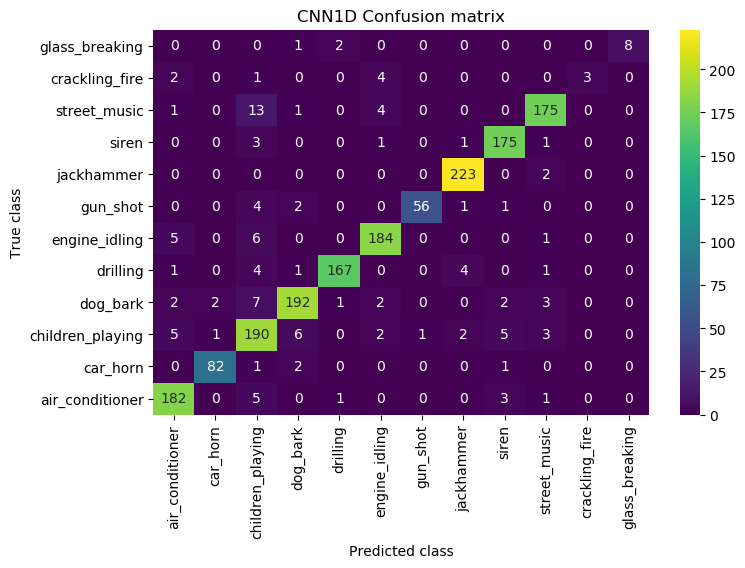

In [11]:
#training propose CNN1D algorithm using 80% training features and then perform prediction on 20% test data to calculate 
#CNN1D prediction accuracy
X_train1 = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test1 = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

#defining cnn1d algorithm layers to train NLP event features extracted from audio file
cnn1d_model = Sequential()
#defining CNN layers with number of neuron as 32 to filter dataset features
cnn1d_model.add(Conv1D(filters=32, kernel_size = 1, activation = 'relu', input_shape = (X_train1.shape[1], X_train1.shape[2])))
cnn1d_model.add(MaxPooling1D(pool_size = 2))
cnn1d_model.add(Conv1D(filters=32, kernel_size = 1, activation = 'relu'))
#adding maxpool layer
cnn1d_model.add(MaxPooling1D(pool_size = 2))
#cnn1d_model.add(Dropout(0.3))
cnn1d_model.add(Flatten())
#defining output layer
cnn1d_model.add(Dense(units = 256, activation = 'relu'))
cnn1d_model.add(Dense(units = y_train.shape[1], activation = 'softmax'))
#compile and train the model
cnn1d_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/cnn1d_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/cnn1d_weights.hdf5', verbose = 1, save_best_only = True)
    hist = cnn1d_model.fit(X_train1, y_train, batch_size = 32, epochs = 50, validation_data=(X_test1, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/cnn1d_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    cnn1d_model.load_weights("model/cnn1d_weights.hdf5")
#perform prediction on test data
predict = cnn1d_model.predict(X_test1)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test, axis=1)
#call this function to calculate accuracy and other metrics
calculateMetrics("CNN1D", predict, y_test1)

In [22]:
ml_acc = accuracy_score(predict, y_test1)
ml_prec = precision_score(predict, y_test1,average='macro')
ml_rec = recall_score(predict, y_test1,average='macro')
ml_f1 = f1_score(predict, y_test1,average='macro')

storeResults('CNN1D',ml_acc,ml_prec,ml_rec,ml_f1)

CNN2D Accuracy  :  94.83834373227454
CNN2D Precision : 95.04379466644458
CNN2D Recall    : 92.47563576404409
CNN2D FScore    : 93.62034225499572


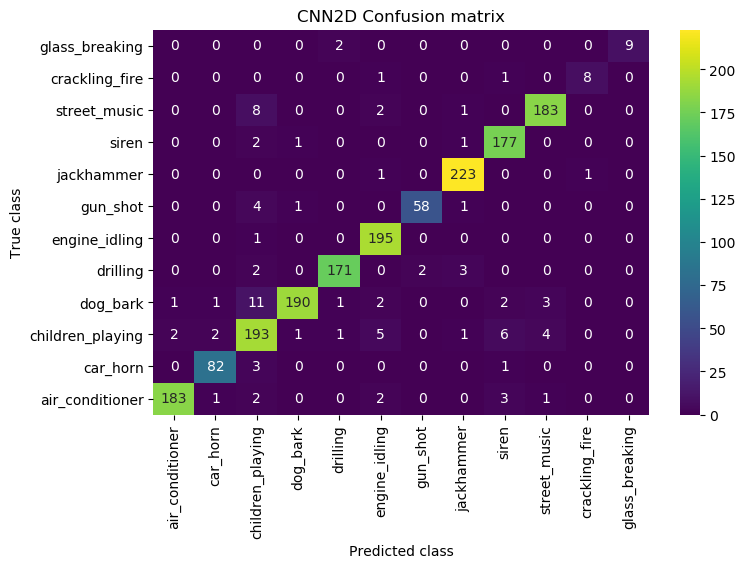

In [12]:
#training CNN2D algorrithm
X_train1 = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1, 1))
X_test1 = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1, 1))
cnn2d_model = Sequential()
#CNN2D filter dataset features using 2 dimension array to collect relevant features
cnn2d_model.add(Convolution2D(32, (1, 1), input_shape = (X_train1.shape[1], X_train1.shape[2], X_train1.shape[3]), activation = 'relu'))
#max layer gather all filtered features from previous layer
cnn2d_model.add(MaxPooling2D(pool_size = (1, 1)))
cnn2d_model.add(Convolution2D(32, (1, 1), activation = 'relu'))
cnn2d_model.add(MaxPooling2D(pool_size = (1, 1)))
cnn2d_model.add(Flatten())
#Defining output layer
cnn2d_model.add(Dense(units = 256, activation = 'relu'))
cnn2d_model.add(Dense(units = y_train.shape[1], activation = 'softmax'))
#compiling, loading and training CNN2D model
cnn2d_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/cnn2d_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/cnn2d_weights.hdf5', verbose = 1, save_best_only = True)
    hist = cnn2d_model.fit(X_train1, y_train, batch_size = 32, epochs = 50, validation_data=(X_test1, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/cnn2d_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    cnn2d_model.load_weights("model/cnn2d_weights.hdf5")
#perform prediction on test data   
predict = cnn2d_model.predict(X_test1)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test, axis=1)
#call this function to calculate accuracy and other metrics
calculateMetrics("CNN2D", predict, y_test1)

In [23]:
ml_acc = accuracy_score(predict, y_test1)
ml_prec = precision_score(predict, y_test1,average='macro')
ml_rec = recall_score(predict, y_test1,average='macro')
ml_f1 = f1_score(predict, y_test1,average='macro')

storeResults('CNN2D',ml_acc,ml_prec,ml_rec,ml_f1)

LSTM Accuracy  :  95.68916619398752
LSTM Precision : 95.08790593270278
LSTM Recall    : 93.42821085166722
LSTM FScore    : 94.15205908330275


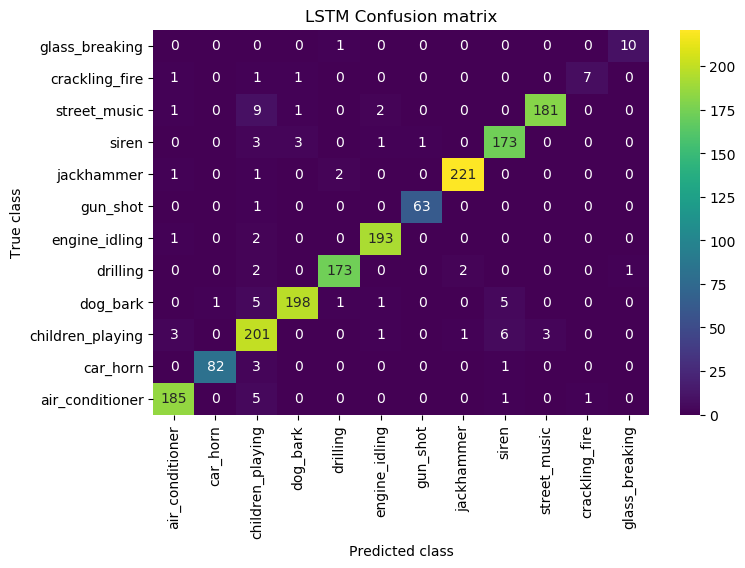

In [13]:
#training LSTM algorithm
X_train1 = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1, 1))
X_test1 = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1, 1))
#defining LSTM to first collect relevant features using CNN and then input to LSTM for classification
lstm_model = Sequential()
lstm_model.add(Convolution2D(32, (1 , 1), input_shape = (X_train1.shape[1], X_train1.shape[2], X_train1.shape[3]), activation = 'relu'))
lstm_model.add(MaxPooling2D(pool_size = (1, 1)))
lstm_model.add(Convolution2D(32, (1, 1), activation = 'relu'))
lstm_model.add(MaxPooling2D(pool_size = (1, 1)))
lstm_model.add(Flatten())
lstm_model.add(RepeatVector(2))
#adding LSTM layer
lstm_model.add(Bidirectional(LSTM(32)))
#defining output layer
lstm_model.add(Dense(units = 256, activation = 'relu'))
lstm_model.add(Dense(units = y_train.shape[1], activation = 'softmax'))
#compiling, training and loading model
lstm_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/lstm_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/lstm_weights.hdf5', verbose = 1, save_best_only = True)
    hist = lstm_model.fit(X_train1, y_train, batch_size = 32, epochs = 50, validation_data=(X_test1, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/lstm_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    lstm_model.load_weights("model/lstm_weights.hdf5")
#perform prediction on test data       
predict = lstm_model.predict(X_test1, batch_size=1)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test, axis=1)
#call this function to calculate accuracy and other metrics
calculateMetrics("LSTM", predict, y_test1)

In [24]:
ml_acc = accuracy_score(predict, y_test1)
ml_prec = precision_score(predict, y_test1,average='macro')
ml_rec = recall_score(predict, y_test1,average='macro')
ml_f1 = f1_score(predict, y_test1,average='macro')

storeResults('LSTM',ml_acc,ml_prec,ml_rec,ml_f1)

Extension Bidirectional GRU Accuracy  :  96.76687464549065
Extension Bidirectional GRU Precision : 96.59943555089926
Extension Bidirectional GRU Recall    : 93.50149235156775
Extension Bidirectional GRU FScore    : 94.880377171139


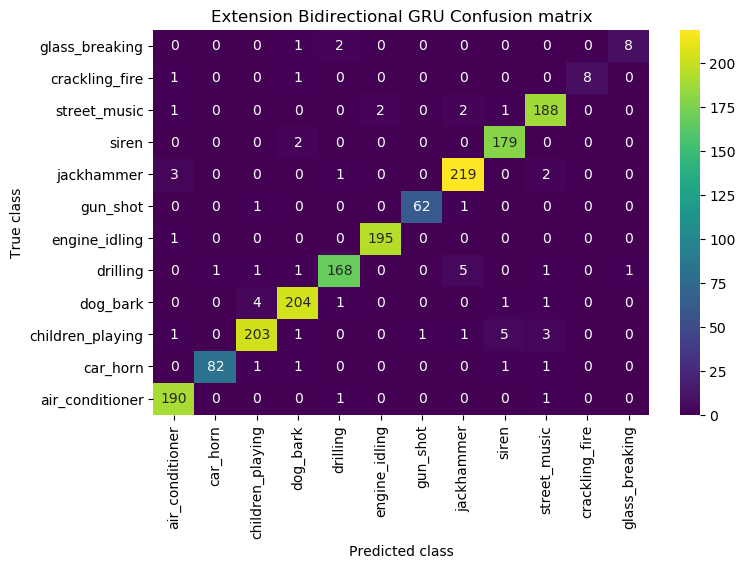

In [14]:
#in paper author said LSTM performance can be further enhance by adding Bidirectional layer with GRU
X_train1 = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1, 1))
X_test1 = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1, 1))

extension_model = Sequential()
extension_model.add(Convolution2D(32, (1 , 1), input_shape = (X_train1.shape[1], X_train1.shape[2], X_train1.shape[3]), activation = 'relu'))
extension_model.add(MaxPooling2D(pool_size = (1, 1)))
extension_model.add(Convolution2D(32, (1, 1), activation = 'relu'))
extension_model.add(MaxPooling2D(pool_size = (1, 1)))
extension_model.add(Flatten())
extension_model.add(RepeatVector(2))
extension_model.add(Bidirectional(GRU(32)))#adding GRU layer inplace of LSTM
extension_model.add(Dense(units = 256, activation = 'relu'))
extension_model.add(Dense(units = y_train.shape[1], activation = 'softmax'))
extension_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/extension_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/extension_weights.hdf5', verbose = 1, save_best_only = True)
    hist = extension_model.fit(X_train1, y_train, batch_size = 32, epochs = 50, validation_data=(X_test1, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/extension_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    extension_model.load_weights("model/extension_weights.hdf5")
#perform prediction on test data
predict = extension_model.predict(X_test1)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test, axis=1)
#call this function to calculate accuracy and other metrics
calculateMetrics("Extension Bidirectional GRU", predict, y_test1)

In [25]:
ml_acc = accuracy_score(predict, y_test1)
ml_prec = precision_score(predict, y_test1,average='macro')
ml_rec = recall_score(predict, y_test1,average='macro')
ml_f1 = f1_score(predict, y_test1,average='macro')

storeResults('Extension Bidirectional GRU',ml_acc,ml_prec,ml_rec,ml_f1)

# Comparison

In [26]:
#creating dataframe
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : acc,
                       'Precision': prec, 
                       'f1_score' : f1,
                        'Recall'   : rec,
                        
                      })

In [27]:
result

,ML Model,Accuracy,Precision,f1_score,Recall
0,CNN1D,92.85,94.68,88.60,86.11
1,CNN2D,94.84,95.04,93.62,92.48
2,LSTM,95.69,95.09,94.15,93.43
3,Extension Bidirectional GRU,96.77,96.60,94.88,93.50


# Graph

In [28]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Accuracy

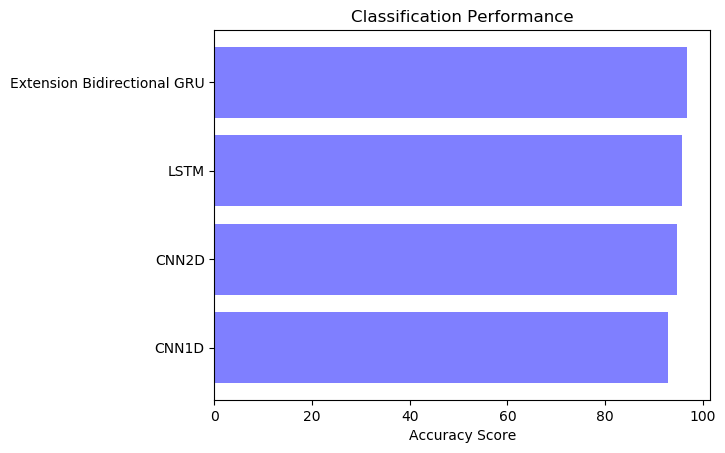

In [29]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, acc, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

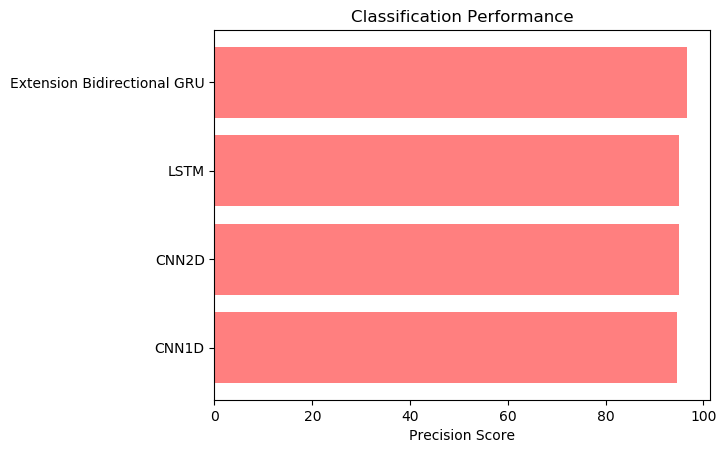

In [30]:
plt2.barh(y_pos, prec, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# Recall

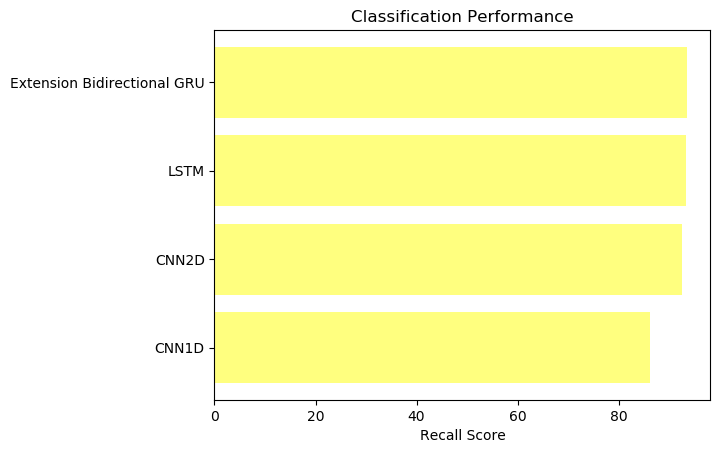

In [31]:
plt2.barh(y_pos, rec, align='center', alpha=0.5,color='yellow')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

# F1 Score

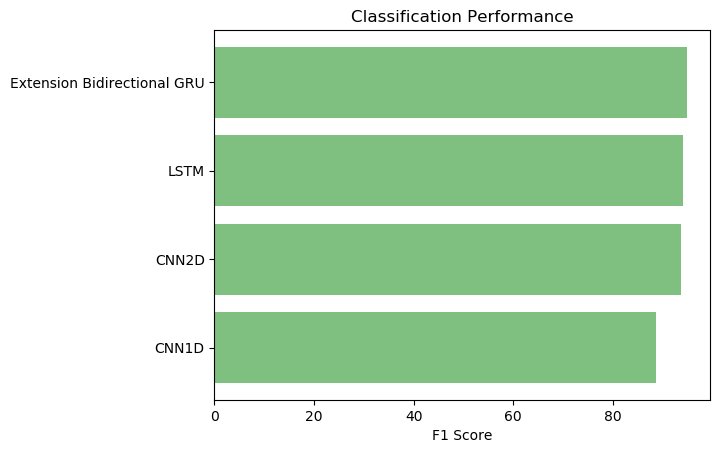

In [32]:
plt2.barh(y_pos, f1, align='center', alpha=0.5,color='green')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()